# Часть 1 — Анализ FastQC

С помощью SRA Explorer скачали 4 файла до 1000 Mb из PRJEB84057:
 - ERR14230582_Illumina_HiSeq_4000_sequencing.fastq.gz
 - ERR14230595_Illumina_HiSeq_4000_sequencing.fastq.gz
 - ERR14230586_Illumina_HiSeq_4000_sequencing.fastq.gz  
 - ERR14230600_Illumina_HiSeq_4000_sequencing.fastq.gz

Написали SLURM-скрипт, который запускает fastqc на этих скачанных данных и агрегирует все отчеты в один с помощью multiqc

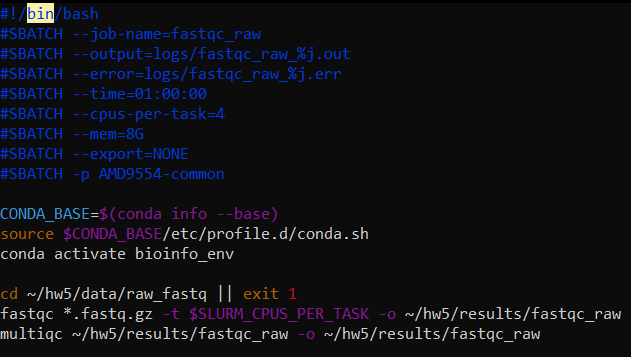

Результаты работы `fastqc` можно найти `results -> fastqc_raw`

### Описание MultiQC Report
 - `Per Base Sequence Content`: В начале чтений (первые 10-15 bp) наблюдается дисбаланс оснований
 - `Per Sequence GC Content`: Распределение GC-состава отклоняется от теоретической нормальной кривой. Это обычно коррелирует с наличием перепредставленных последовательностей
 - `Sequence Length Distribution`: разброс длин чтений в диапазоне от 30 до 75 bp
 - `Overrepresented sequences`: Повторы вида TGTGTGTG... и CACACACA.... могут указывать на наличие артефактов ПЦР-амплификации
 - `Adapter Content`: No samples found with any adapter contamination > 0.1%
 - `Per Base Sequence Quality`: участков с плохим качеством в концах ридов нет

#  Тримминг

 - Есть ли в ваших данных адаптеры?
     - см. выше - нет
 - Есть ли участки с плохим качеством (Q<20) в конце ридов?
    - см выше - нет
    
Написали SLURM-скрипт для запуска fastp
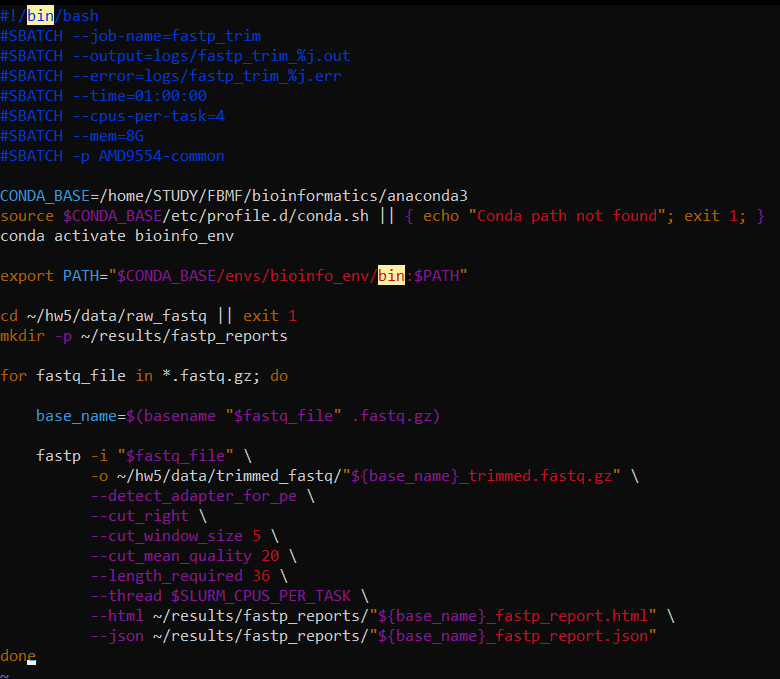

 - Обрежет адаптеры: `--detect_adapter_for_pe`
 - Применит скользящее окно (5:20) для удаления плохих участков: `--cut_right --cut_window_size 5 --cut_mean_quality 20`
 - Отбросит риды короче 36 п.н.: `--length_required 36`
 

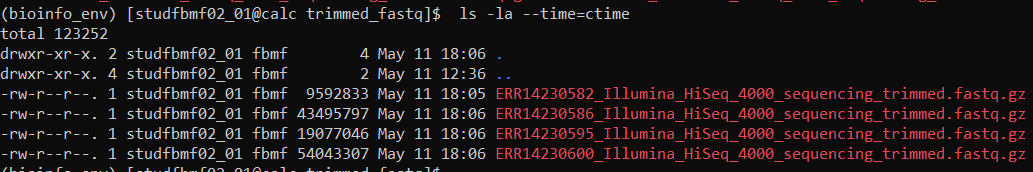

#  Контроль качества после тримминга
Запустили `fastqc` повторно на *_trimmed.fastq.gz и снова собрали отчет `multiqc`

### Описание MultiQC Report и отличия
 - `Data Yield`: Общее количество оснований (Total Bases) в отчете уменьшилось
 - `Sequence Length Distribution`: разброс длин чтений остался похожим но теперь появилось смещение левого края на 36 п.н.
 - `Overrepresented sequences`: проблема повторов осталась, fastp с ней не разделался 
 - `Adapter Content`: No samples found with any adapter contamination > 0.1%, теперь адаптеров точно нет
 - `Per Base Sequence Quality`: Исчезли резкие провалы в красную зону (ниже Q20) в конце чтений, так как fastp отрезал плохие хвосты.

# Выводы
 - Выбранные файлы оказались уже высокого качества
 - Адаптеры не обнаруживаются
 - Изменения за счёт среза хвоста и фильтра коротких ридов